# Thesis Evaluation Notebook

Loads `.pkl` result files and produces all thesis plots.

**Only configure Cell 2** — change `RESULTS_DIR`, `MAX_CALLS`, `VARIANTS`, `DIMENSIONS` there.

In [1]:
import os, sys, pickle
import numpy as np
import torch
import matplotlib.pyplot as plt

module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from src.evaluate import postprocessing_interpolation_rewards, f_max_new

In [2]:
#RESULTS_DIR = '../experiments/thesis_experiments/results_quick'
RESULTS_DIR = '../experiments/thesis_experiments/results_160426_A'  # full experiment

#FIGURES_DIR = '../experiments/thesis_experiments/figures_quick'
FIGURES_DIR = '../experiments/thesis_experiments/figures'  # full experiment

MAX_CALLS = 300    # 10 for quick, 300 for full

#VARIANTS = [
 #   ('gibo_baseline_quick',   'GIBO Baseline'),
 #   ('gibo_prob_wolfe_quick', 'Prob Wolfe'),
 #   ('gibo_det_ei_quick',     'Det EI'),
#]
# For full experiment:
VARIANTS = [
     ('gibo_baseline',   'GIBO Baseline'),
     ('gibo_prob_wolfe', 'Prob Wolfe'),
     ('gibo_det_ei',     'Det EI'),
]

DIMENSIONS = [4, 8, 12, 16, 20, 24, 28, 32, 36]

# Create figures directory
os.makedirs(FIGURES_DIR, exist_ok=True)
print(f'Figures will be saved to: {FIGURES_DIR}')

Figures will be saved to: ../experiments/thesis_experiments/figures


## Block 1: Load pkl Files

In [3]:
def load_variant(results_dir, name, dimensions):
    data = {k: {} for k in [
        'calls', 'best_so_far', 'f_max',
        'inner_loop_samples', 'step_sizes', 'gradient_norms',
        'p_wolfe_values', 'wolfe_satisfied', 'armijo_ok', 'curvature_ok',
    ]}
    for dim in dimensions:
        dim_dir = os.path.join(results_dir, name, f'dim_{dim}')
        if not os.path.isdir(dim_dir):
            continue
        pkl_files = sorted(f for f in os.listdir(dim_dir) if f.endswith('.pkl'))
        if not pkl_files:
            continue
        calls_d, bsf_d, fmax_d = [], [], []
        ils_d, ss_d, gn_d = [], [], []
        pw_d, ws_d, arm_d, cur_d = [], [], [], []
        for fname in pkl_files:
            with open(os.path.join(dim_dir, fname), 'rb') as fh:
                r = pickle.load(fh)
            fmv    = float(r['f_max'])
            regret = r['regret_per_eval']
            calls  = r['calls_at_iteration']
            bsf    = [fmv - rg for rg in regret]
            calls_d.append(calls)
            bsf_d.append([0.0] + bsf)
            fmax_d.append(fmv)
            ils_d.append(r.get('inner_loop_samples', []))
            ss_d.append(r.get('step_sizes', []))
            gn_d.append(r.get('gradient_norms', []))
            pw_d.append(r.get('p_wolfe_values', []))
            ws_d.append(r.get('wolfe_satisfied', []))
            arm_d.append(r.get('armijo_ok', []))
            cur_d.append(r.get('curvature_ok', []))
        data['calls'][dim]              = calls_d
        data['best_so_far'][dim]        = bsf_d
        data['f_max'][dim]              = fmax_d
        data['inner_loop_samples'][dim] = ils_d
        data['step_sizes'][dim]         = ss_d
        data['gradient_norms'][dim]     = gn_d
        data['p_wolfe_values'][dim]     = pw_d
        data['wolfe_satisfied'][dim]    = ws_d
        data['armijo_ok'][dim]          = arm_d
        data['curvature_ok'][dim]       = cur_d
        print(f'  dim={dim}: {len(pkl_files)} runs')
    return data


all_data = {}
for vname, vlabel in VARIANTS:
    print(f'Loading {vlabel} ({vname}) ...')
    all_data[vname] = load_variant(RESULTS_DIR, vname, DIMENSIONS)

available_dims = [
    d for d in DIMENSIONS
    if all(d in all_data[vn]['calls'] for vn, _ in VARIANTS)
]
print(f'\nAvailable dims: {available_dims}')

Loading GIBO Baseline (gibo_baseline) ...
  dim=4: 30 runs
  dim=8: 30 runs
  dim=12: 30 runs
  dim=16: 30 runs
  dim=20: 30 runs
  dim=24: 30 runs
  dim=28: 30 runs
  dim=32: 30 runs
  dim=36: 30 runs
Loading Prob Wolfe (gibo_prob_wolfe) ...
  dim=4: 30 runs
  dim=8: 30 runs
  dim=12: 30 runs
  dim=16: 30 runs
  dim=20: 30 runs
  dim=24: 30 runs
  dim=28: 30 runs
  dim=32: 30 runs
  dim=36: 30 runs
Loading Det EI (gibo_det_ei) ...
  dim=4: 30 runs
  dim=8: 30 runs
  dim=12: 30 runs
  dim=16: 30 runs
  dim=20: 30 runs
  dim=24: 30 runs
  dim=28: 30 runs
  dim=32: 30 runs
  dim=36: 30 runs

Available dims: [4, 8, 12, 16, 20, 24, 28, 32, 36]


## Block 2: Interpolate to Common Call Grid

In [4]:
def interpolate_rewards(rewards_dict, calls_dict, max_calls):
    """
    Robust replacement for postprocessing_interpolation_rewards.
    Handles cases where last call < max_calls - 1 (avoids IndexError).

    rewards_dict : {dim: [[r0, r1, ...], ...]}  len(rewards) = len(calls) + 1
    calls_dict   : {dim: [[c0, c1, ...], ...]}
    Returns      : Tensor (n_dims, n_runs, max_calls)
    """
    dimensions = list(rewards_dict.keys())
    n_runs = len(rewards_dict[dimensions[0]])
    out = torch.zeros(len(dimensions), n_runs, max_calls)
    for idx_d, dim in enumerate(dimensions):
        for idx_r in range(n_runs):
            rewards = rewards_dict[dim][idx_r]
            calls   = calls_dict[dim][idx_r]
            ir = 0
            for call in range(max_calls):
                if ir < len(calls) and call == calls[ir]:
                    ir += 1
                out[idx_d, idx_r, call] = rewards[ir]
    return out


interpolated = {}
for vname, vlabel in VARIANTS:
    d = all_data[vname]
    rewards_dict = {dim: d['best_so_far'][dim] for dim in available_dims}
    calls_dict   = {dim: d['calls'][dim]       for dim in available_dims}
    interpolated[vname] = interpolate_rewards(rewards_dict, calls_dict, MAX_CALLS)
    print(f'{vlabel}: {interpolated[vname].shape}')

first_vname     = VARIANTS[0][0]
f_max_dict      = {dim: all_data[first_vname]['f_max'][dim] for dim in available_dims}
f_max_corrected = f_max_new(f_max_dict, list(interpolated.values()))

names   = [label for _, label in VARIANTS]
tensors = [interpolated[vname] for vname, _ in VARIANTS]

GIBO Baseline: torch.Size([9, 30, 300])
Prob Wolfe: torch.Size([9, 30, 300])
Det EI: torch.Size([9, 30, 300])


## Block 3: Regret vs Evaluations

Saved: ../experiments/thesis_experiments/figures\regret_vs_evals.pdf


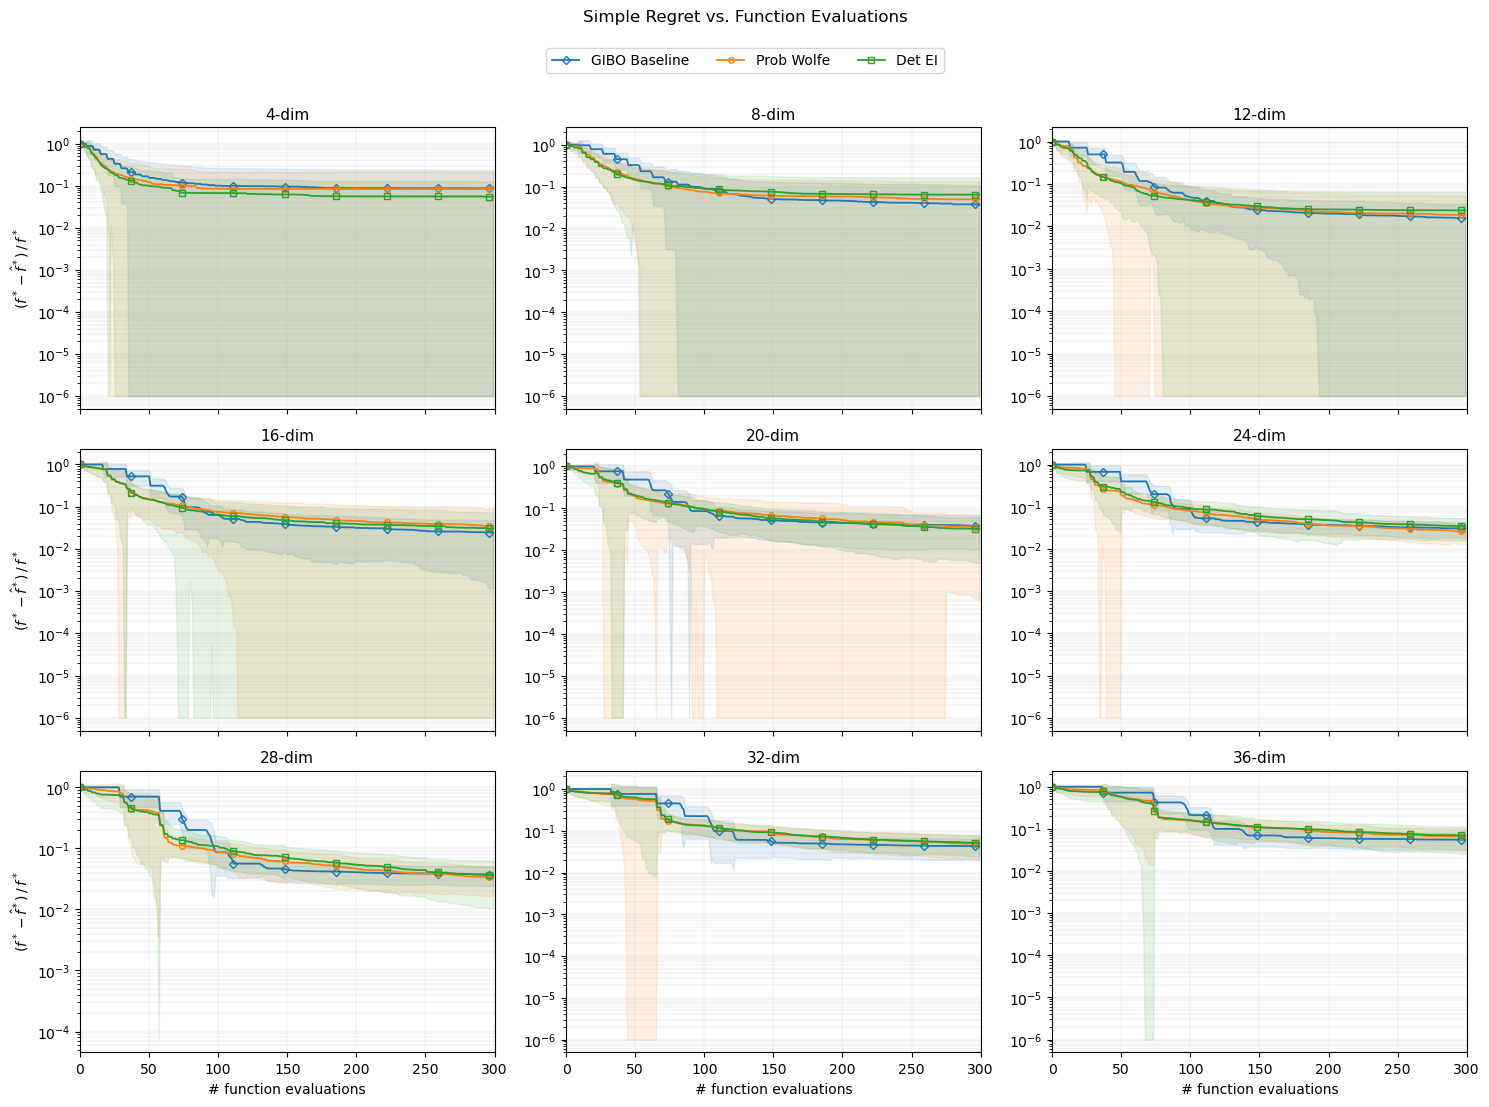

In [5]:
def plot_regret(f_max, rewards_list, names, available_dims, max_calls, show_std=True, path=None):
    markers = ['D', 'o', 's']
    colors  = ['#1f77b4', '#ff7f0e', '#2ca02c']
    n      = len(available_dims)
    n_cols = 3
    n_rows = int(np.ceil(n / n_cols))
    x = np.arange(max_calls)

    fig, axs = plt.subplots(n_rows, n_cols, sharex=True, sharey=False,
                             figsize=(5 * n_cols, 3.5 * n_rows))
    axs = np.array(axs).reshape(-1)

    for idx_d, dim in enumerate(available_dims):
        ax  = axs[idx_d]
        fmx = np.array(f_max[dim]).reshape(-1, 1)
        ax.set_title(f'{dim}-dim', fontsize=11)
        ax.set_xlim([0, max_calls])
        if idx_d >= n_cols * (n_rows - 1):
            ax.set_xlabel('# function evaluations', labelpad=5)
        if idx_d % n_cols == 0:
            ax.set_ylabel(r'$(f^* - \hat{f}^*)\,/\,f^*$')

        for idx_o, (rew, name) in enumerate(zip(rewards_list, names)):
            rew_np = rew[idx_d].numpy()
            err    = (fmx - rew_np) / fmx
            err    = np.clip(err, 1e-6, None)
            mean   = err.mean(0)
            std    = err.std(0)
            ax.plot(x, mean, label=name,
                    marker=markers[idx_o],
                    markevery=max(1, max_calls // 8),
                    markersize=4, linewidth=1.3,
                    color=colors[idx_o], fillstyle='none')
            if show_std:
                ax.fill_between(x,
                                np.clip(mean - std, 1e-6, None),
                                mean + std,
                                alpha=0.12, color=colors[idx_o])

        ax.set_yscale('log')
        ax.yaxis.grid(True, which='both', linewidth=0.3, alpha=0.5)
        ax.xaxis.grid(True, linewidth=0.3, alpha=0.4)

    for idx in range(len(available_dims), n_rows * n_cols):
        axs[idx].set_visible(False)

    handles, labels = axs[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center',
               bbox_to_anchor=(0.5, 1.02), ncol=len(names),
               frameon=True, fontsize=10)
    fig.suptitle('Simple Regret vs. Function Evaluations', fontsize=12, y=1.05)
    plt.tight_layout()
    if path:
        plt.savefig(path, bbox_inches='tight')
        print(f'Saved: {path}')
    plt.show()


plot_regret(f_max_corrected, tensors, names, available_dims, MAX_CALLS, show_std=True,
            path=os.path.join(FIGURES_DIR, 'regret_vs_evals.pdf'))

## Block 4: Final Regret Boxplots over Dimensions

Saved: ../experiments/thesis_experiments/figures\boxplots_final_regret.pdf


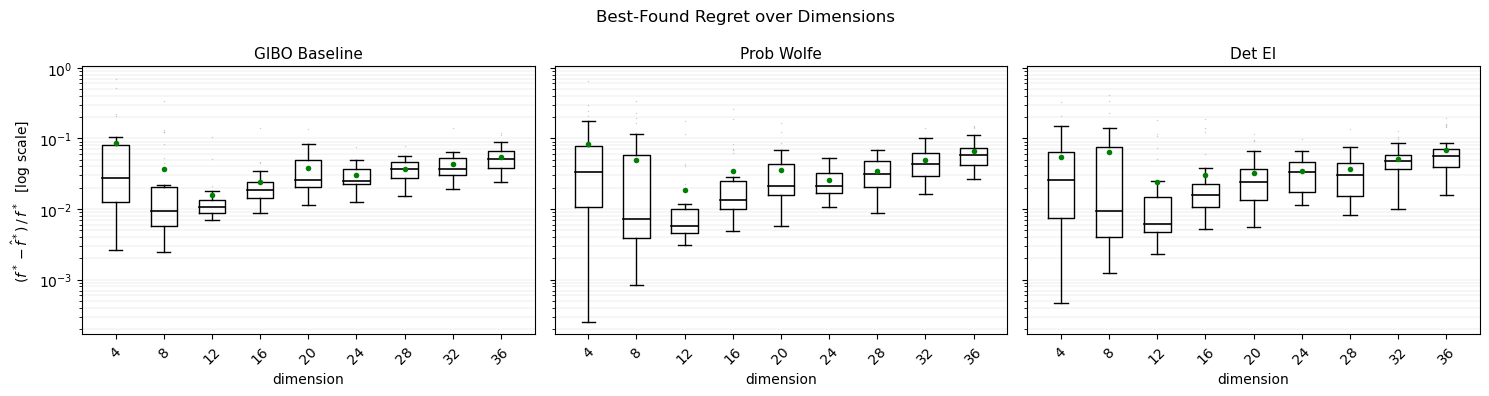

In [6]:
def plot_boxplots(f_max, rewards_list, names, available_dims, path=None):
    n_opt  = len(rewards_list)
    fig, axs = plt.subplots(1, n_opt, sharex=True, sharey=True, figsize=(5 * n_opt, 4))
    if n_opt == 1:
        axs = [axs]

    medp   = dict(linestyle='-', linewidth=1.2, color='black')
    meanp  = dict(marker='o', markerfacecolor='green', markersize=4, markeredgecolor='none')
    flierp = dict(marker='.', markerfacecolor='gray', markersize=2, alpha=0.4,
                  markeredgecolor='none')

    for idx, (rew, name) in enumerate(zip(rewards_list, names)):
        fve = []
        for idx_d, dim in enumerate(available_dims):
            fmx  = torch.tensor(f_max[dim])
            maxr = rew[idx_d].max(-1).values
            vals = ((fmx - maxr) / fmx).numpy()
            vals = np.clip(vals, 1e-4, None)   # avoid log(0)
            fve.append(vals)

        axs[idx].boxplot(fve, positions=available_dims, widths=2.2,
                         showfliers=True, showmeans=True,
                         meanprops=meanp, medianprops=medp,
                         flierprops=flierp)
        axs[idx].set_yscale('log')
        axs[idx].yaxis.grid(True, which='both', linewidth=0.3, alpha=0.5)
        axs[idx].set_xlabel('dimension')
        axs[idx].set_title(name, fontsize=11)
        axs[idx].set_xticks(available_dims)
        axs[idx].tick_params(axis='x', labelrotation=45)

    axs[0].set_ylabel(r'$(f^* - \hat{f}^*)\,/\,f^*$  [log scale]')
    plt.suptitle('Best-Found Regret over Dimensions', fontsize=12)
    plt.tight_layout()
    if path:
        plt.savefig(path, bbox_inches='tight')
        print(f'Saved: {path}')
    plt.show()


plot_boxplots(f_max_corrected, tensors, names, available_dims,
              path=os.path.join(FIGURES_DIR, 'boxplots_final_regret.pdf'))

## Block 5: RQ1 — Inner Loop Sample Counts

Saved: ../experiments/thesis_experiments/figures\inner_loop_samples.pdf


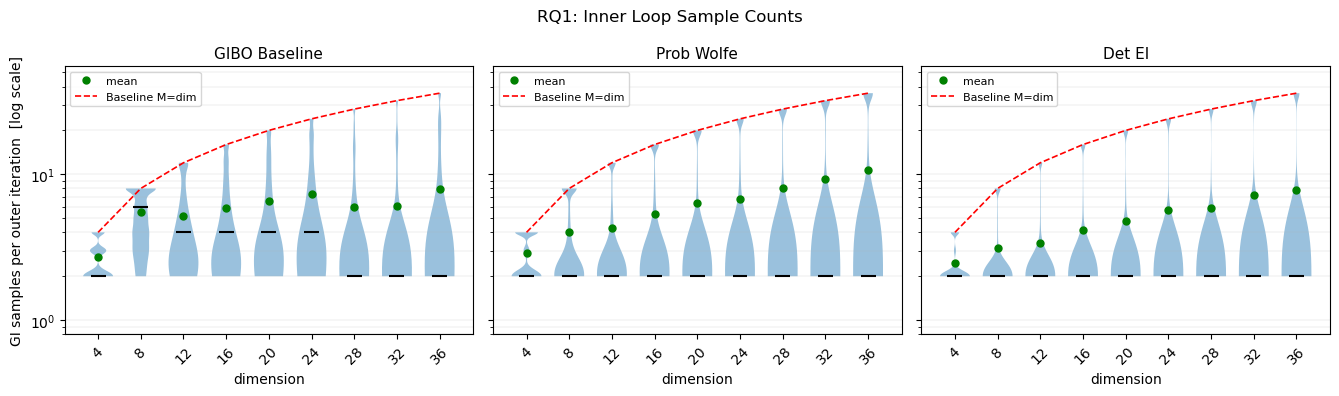

  Dim         GIBO Baseline            Prob Wolfe                Det EI
-------------------------------------------------------------------------
    4    2.72 (med  2.0)    2.88 (med  2.0)    2.47 (med  2.0)  
    8    5.49 (med  6.0)    4.05 (med  2.0)    3.10 (med  2.0)  
   12    5.14 (med  4.0)    4.26 (med  2.0)    3.36 (med  2.0)  
   16    5.86 (med  4.0)    5.38 (med  2.0)    4.15 (med  2.0)  
   20    6.59 (med  4.0)    6.32 (med  2.0)    4.76 (med  2.0)  
   24    7.34 (med  4.0)    6.80 (med  2.0)    5.65 (med  2.0)  
   28    5.97 (med  2.0)    8.03 (med  2.0)    5.90 (med  2.0)  
   32    6.03 (med  2.0)    9.32 (med  2.0)    7.26 (med  2.0)  
   36    7.94 (med  2.0)   10.63 (med  2.0)    7.84 (med  2.0)  


In [7]:
def plot_inner_samples(all_data, variants, available_dims, path=None):
    n = len(variants)
    fig, axs = plt.subplots(1, n, sharex=True, sharey=True, figsize=(4.5 * n, 4))
    if n == 1:
        axs = [axs]

    for idx, (vname, vlabel) in enumerate(variants):
        ax = axs[idx]
        data_per_dim = []
        means = []
        for dim in available_dims:
            vals = []
            for run in all_data[vname]['inner_loop_samples'].get(dim, []):
                vals.extend([s for s in run if s is not None])
            vals = vals if vals else [0]
            data_per_dim.append(np.array(vals, dtype=float))
            means.append(np.mean(vals))

        # Violin plot — shows bimodal shape
        parts = ax.violinplot(data_per_dim, positions=available_dims,
                              widths=2.8, showmedians=True,
                              showextrema=False)
        for pc in parts['bodies']:
            pc.set_alpha(0.45)
        parts['cmedians'].set_linewidth(1.5)
        parts['cmedians'].set_color('black')

        # Mean as green dot
        ax.plot(available_dims, means, 'o', color='green',
                markersize=5, zorder=5, label='mean')

        # Baseline M=dim reference
        ax.plot(available_dims, available_dims, 'r--', lw=1.2, label='Baseline M=dim')

        ax.set_yscale('log')
        ax.set_ylim([0.8, 55])
        ax.yaxis.grid(True, which='both', linewidth=0.3, alpha=0.5)
        ax.set_title(vlabel, fontsize=11)
        ax.set_xlabel('dimension')
        ax.set_xticks(available_dims)
        ax.tick_params(axis='x', labelrotation=45)
        ax.legend(fontsize=8)

    axs[0].set_ylabel('GI samples per outer iteration  [log scale]')
    plt.suptitle('RQ1: Inner Loop Sample Counts', fontsize=12)
    plt.tight_layout()
    if path:
        plt.savefig(path, bbox_inches='tight')
        print(f'Saved: {path}')
    plt.show()

    # Numeric summary
    print(f"{'Dim':>5}  " + '  '.join(f'{lb:>20}' for _, lb in variants))
    print('-' * (7 + 22 * len(variants)))
    for dim in available_dims:
        row = f'{dim:>5}  '
        for vname, _ in variants:
            vals = []
            for run in all_data[vname]['inner_loop_samples'].get(dim, []):
                vals.extend([s for s in run if s is not None])
            if vals:
                a = np.array(vals)
                row += f'{np.mean(a):6.2f} (med {np.median(a):4.1f})  '
            else:
                row += f'{"n/a":>20}  '
        print(row)


plot_inner_samples(all_data, VARIANTS, available_dims,
                   path=os.path.join(FIGURES_DIR, 'inner_loop_samples.pdf'))

## Block 6: RQ2 — Step Size Distribution

Saved: ../experiments/thesis_experiments/figures\step_sizes.pdf


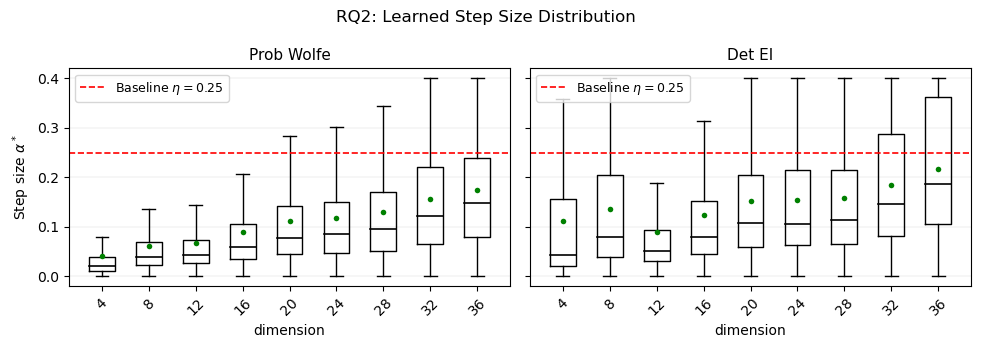

In [8]:
def plot_step_sizes(all_data, variants, available_dims, path=None):
    # Only show variants that actually use a line-search step size
    ls_variants = [(vn, lb) for vn, lb in variants if 'baseline' not in vn]
    if not ls_variants:
        print('No line-search variants found — skipping step size plot.')
        return

    n = len(ls_variants)
    fig, axs = plt.subplots(1, n, sharex=True, sharey=True, figsize=(5 * n, 3.5))
    if n == 1:
        axs = [axs]

    medp  = dict(linestyle='-', linewidth=1.2, color='black')
    meanp = dict(marker='o', markerfacecolor='green', markersize=4, markeredgecolor='none')

    for idx, (vname, vlabel) in enumerate(ls_variants):
        data_per_dim = []
        for dim in available_dims:
            vals = []
            for run in all_data[vname]['step_sizes'].get(dim, []):
                vals.extend([a for a in run if a is not None])
            data_per_dim.append(vals if vals else [0.0])

        axs[idx].boxplot(data_per_dim, positions=available_dims, widths=2.2,
                         showfliers=False, showmeans=True,
                         meanprops=meanp, medianprops=medp)
        axs[idx].axhline(0.25, color='r', linestyle='--', lw=1.2,
                         label='Baseline $\\eta=0.25$')
        axs[idx].yaxis.grid(True, linewidth=0.3, alpha=0.5)
        axs[idx].set_title(vlabel, fontsize=11)
        axs[idx].set_xlabel('dimension')
        axs[idx].set_xticks(available_dims)
        axs[idx].tick_params(axis='x', labelrotation=45)
        axs[idx].legend(fontsize=9)

    axs[0].set_ylabel(r'Step size $\alpha^*$')
    plt.suptitle('RQ2: Learned Step Size Distribution', fontsize=12)
    plt.tight_layout()
    if path:
        plt.savefig(path, bbox_inches='tight')
        print(f'Saved: {path}')
    plt.show()


plot_step_sizes(all_data, VARIANTS, available_dims,
                path=os.path.join(FIGURES_DIR, 'step_sizes.pdf'))

## Block 7: RQ4 — Inner Loop Length over Iterations (Early vs Late)

Saved: ../experiments/thesis_experiments/figures\inner_loop_over_iters_dim4.pdf


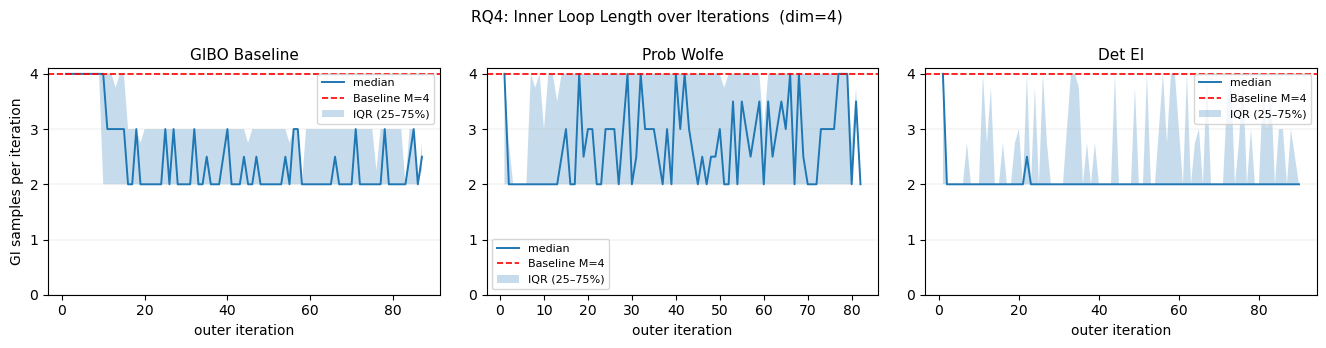

Saved: ../experiments/thesis_experiments/figures\inner_loop_over_iters_dim8.pdf


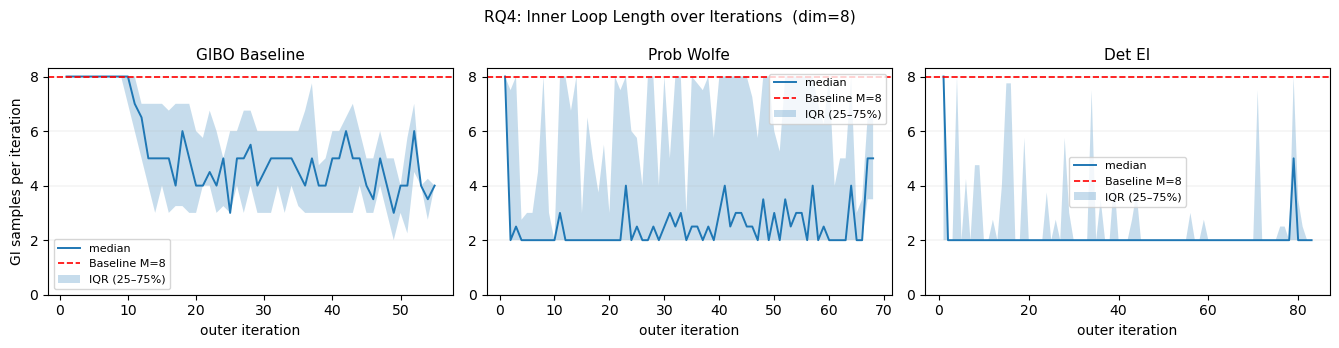

Saved: ../experiments/thesis_experiments/figures\inner_loop_over_iters_dim12.pdf


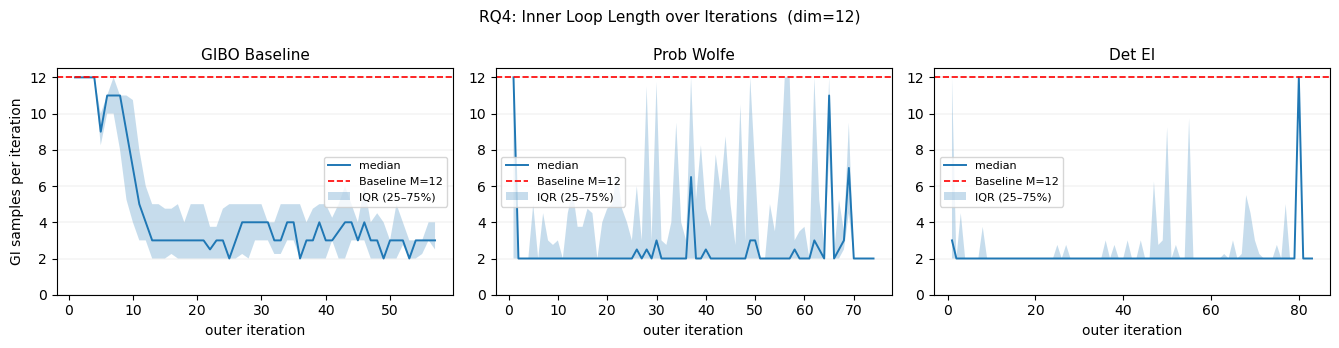

Saved: ../experiments/thesis_experiments/figures\inner_loop_over_iters_dim16.pdf


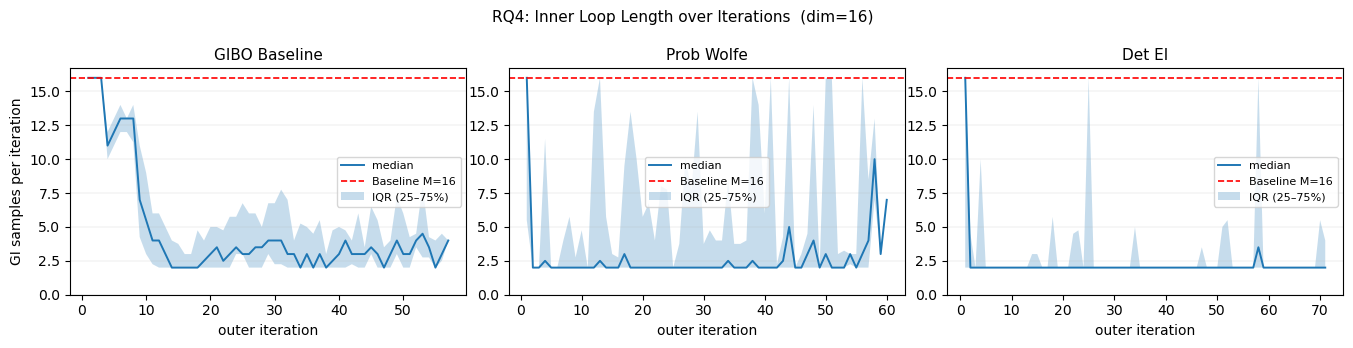

Saved: ../experiments/thesis_experiments/figures\inner_loop_over_iters_dim20.pdf


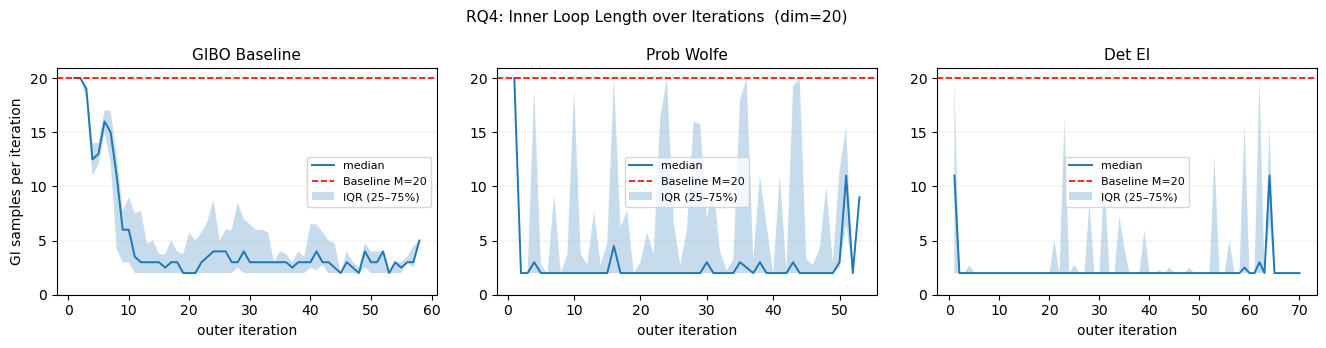

Saved: ../experiments/thesis_experiments/figures\inner_loop_over_iters_dim24.pdf


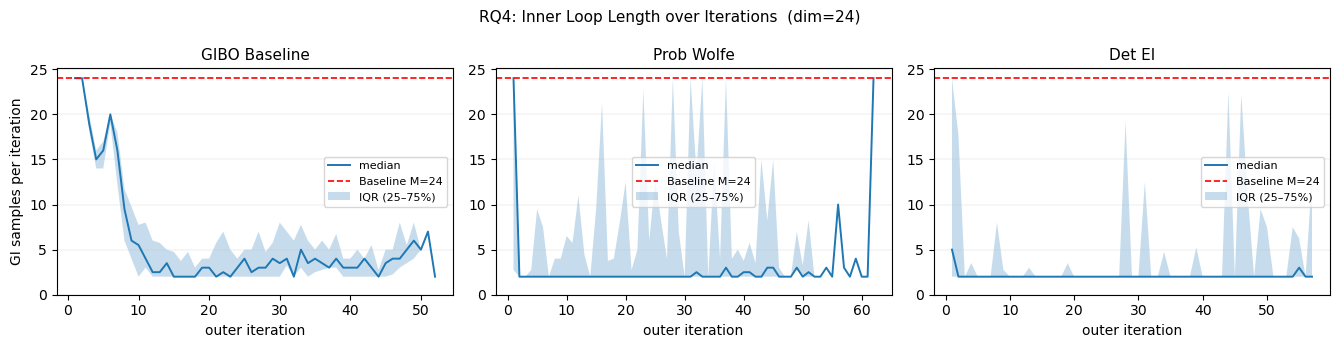

Saved: ../experiments/thesis_experiments/figures\inner_loop_over_iters_dim28.pdf


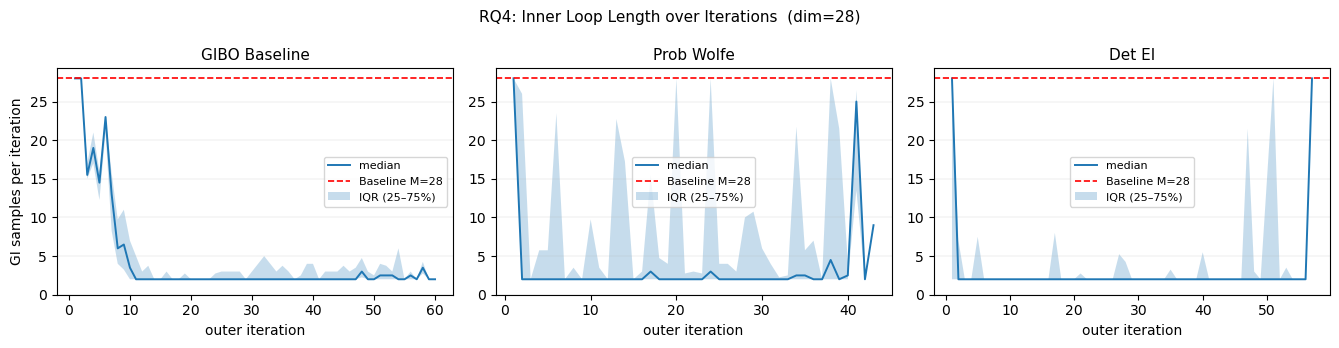

Saved: ../experiments/thesis_experiments/figures\inner_loop_over_iters_dim32.pdf


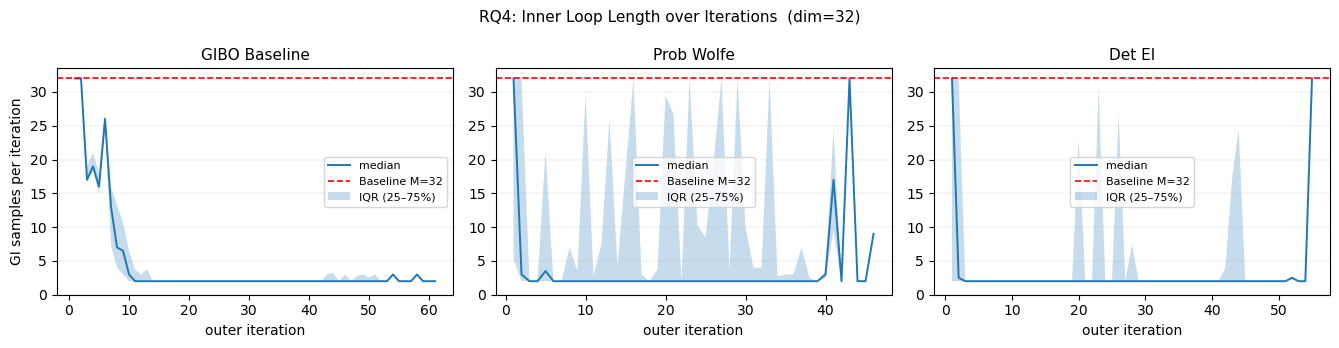

Saved: ../experiments/thesis_experiments/figures\inner_loop_over_iters_dim36.pdf


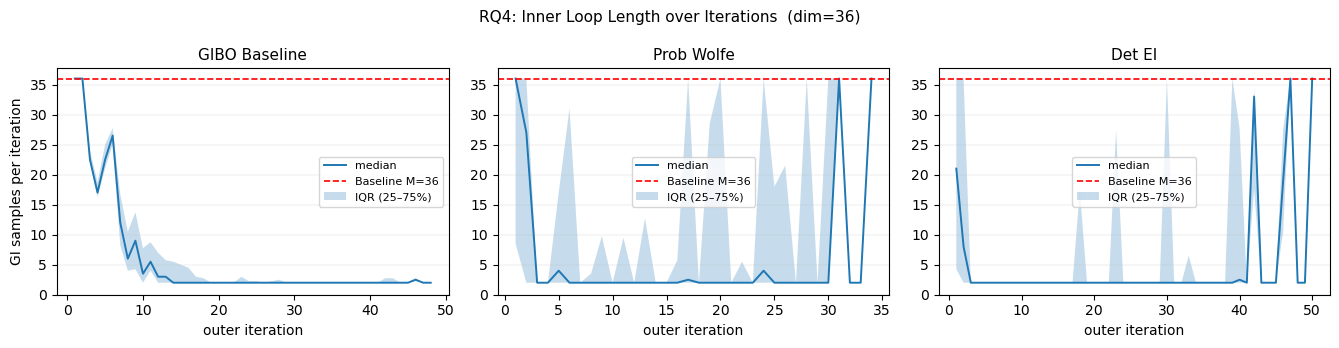

In [9]:
def plot_samples_over_iters(all_data, variants, available_dims, figures_dir=None):
    for dim in available_dims:
        n = len(variants)
        fig, axs = plt.subplots(1, n, sharey=False, figsize=(4.5 * n, 3.5))
        if n == 1:
            axs = [axs]

        for idx, (vname, vlabel) in enumerate(variants):
            ax   = axs[idx]
            runs = all_data[vname]['inner_loop_samples'].get(dim, [])
            if not runs:
                ax.set_title(f'{vlabel}\n(no data)')
                continue

            max_iters = max(len(r) for r in runs)
            padded = np.full((len(runs), max_iters), np.nan)
            for i, r in enumerate(runs):
                vals = [v for v in r if v is not None]
                padded[i, :len(vals)] = vals

            median = np.nanmedian(padded, axis=0)
            q25    = np.nanpercentile(padded, 25, axis=0)
            q75    = np.nanpercentile(padded, 75, axis=0)
            x      = np.arange(1, max_iters + 1)

            ax.plot(x, median, lw=1.4, label='median')
            ax.fill_between(x, q25, q75, alpha=0.25, label='IQR (25–75%)')
            ax.axhline(dim, color='r', linestyle='--', lw=1.2, label=f'Baseline M={dim}')

            ax.set_ylim(bottom=0)
            ax.yaxis.grid(True, linewidth=0.3, alpha=0.5)
            ax.set_title(vlabel, fontsize=11)
            ax.set_xlabel('outer iteration')
            ax.legend(fontsize=8)

        axs[0].set_ylabel('GI samples per iteration')
        plt.suptitle(f'RQ4: Inner Loop Length over Iterations  (dim={dim})', fontsize=11)
        plt.tight_layout()
        if figures_dir:
            path = os.path.join(figures_dir, f'inner_loop_over_iters_dim{dim}.pdf')
            plt.savefig(path, bbox_inches='tight')
            print(f'Saved: {path}')
        plt.show()


plot_samples_over_iters(all_data, VARIANTS, available_dims, figures_dir=FIGURES_DIR)

## Block 8: RQ4 — p_Wolfe Trace (Variant A)

Saved: ../experiments/thesis_experiments/figures\p_wolfe_trace_dim4.pdf


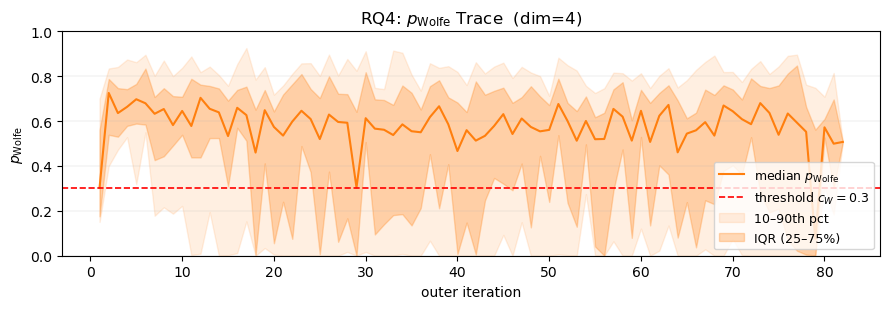

Saved: ../experiments/thesis_experiments/figures\p_wolfe_trace_dim8.pdf


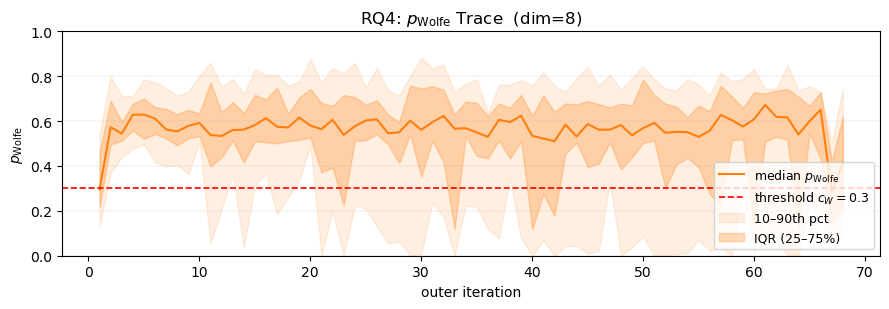

Saved: ../experiments/thesis_experiments/figures\p_wolfe_trace_dim12.pdf


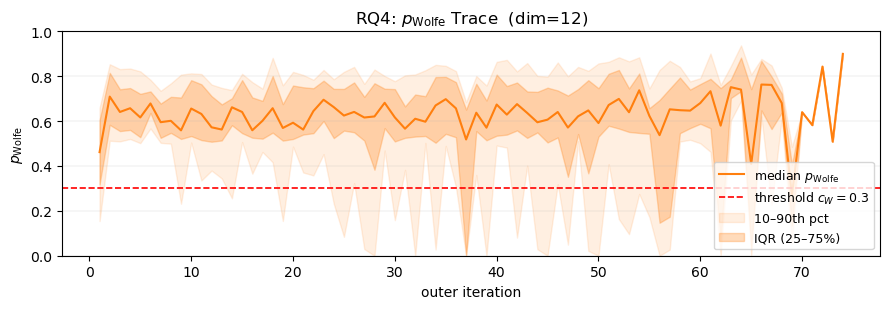

Saved: ../experiments/thesis_experiments/figures\p_wolfe_trace_dim16.pdf


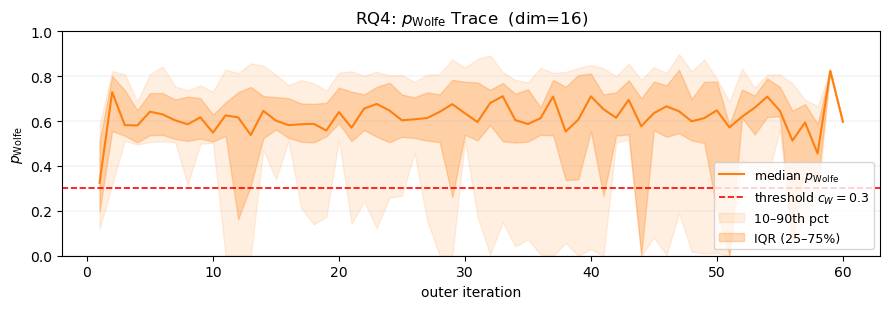

Saved: ../experiments/thesis_experiments/figures\p_wolfe_trace_dim20.pdf


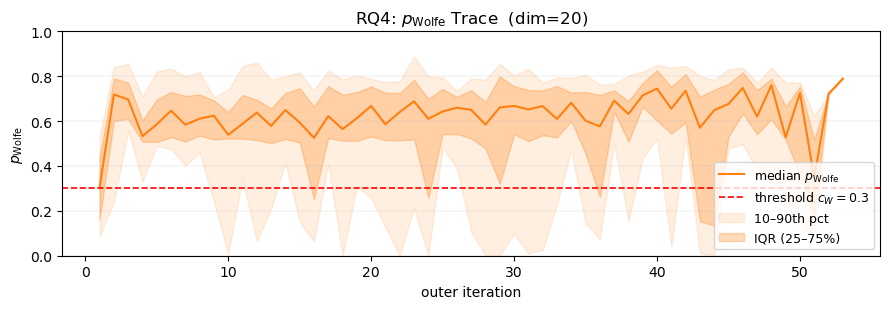

Saved: ../experiments/thesis_experiments/figures\p_wolfe_trace_dim24.pdf


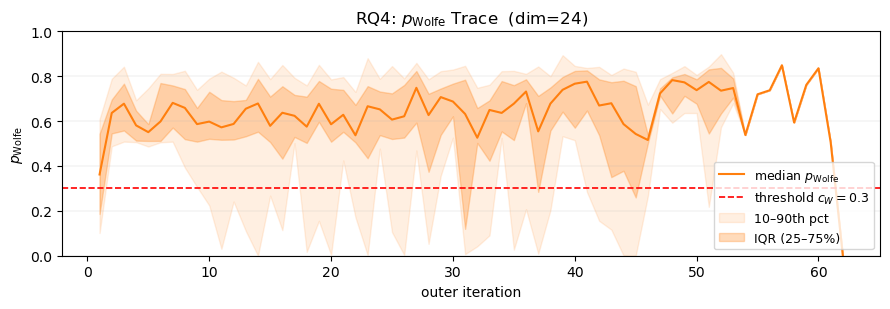

Saved: ../experiments/thesis_experiments/figures\p_wolfe_trace_dim28.pdf


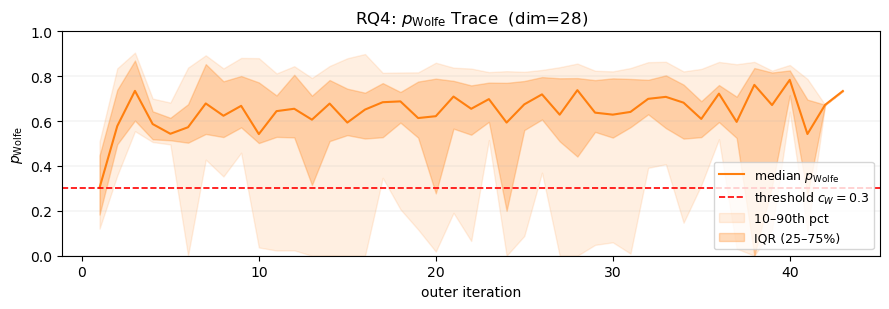

Saved: ../experiments/thesis_experiments/figures\p_wolfe_trace_dim32.pdf


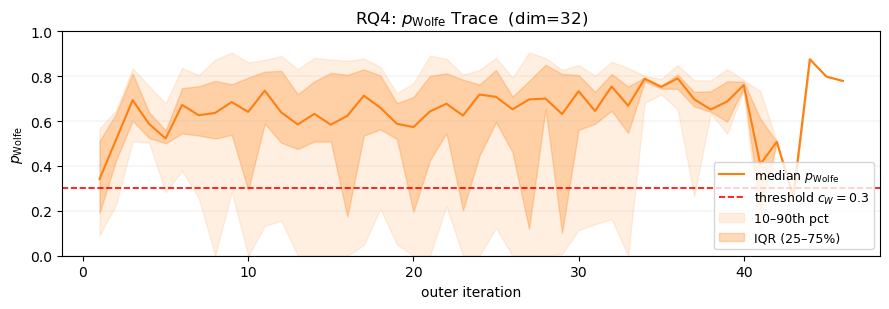

Saved: ../experiments/thesis_experiments/figures\p_wolfe_trace_dim36.pdf


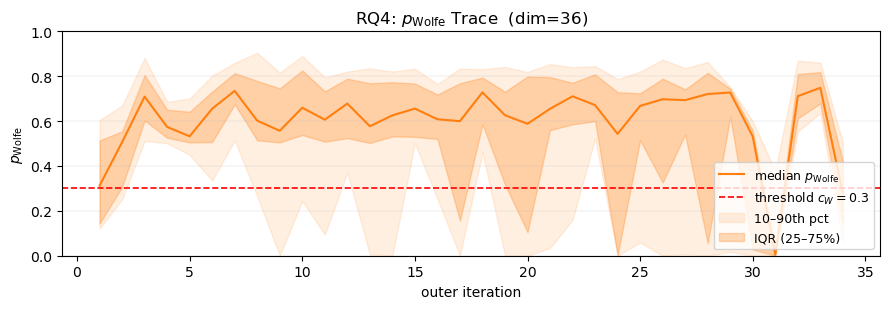

In [10]:
pw_vname = next((vn for vn, _ in VARIANTS if 'prob_wolfe' in vn), None)

if pw_vname is None:
    print('No prob_wolfe variant in VARIANTS — skipping.')
else:
    for dim in available_dims:
        runs = all_data[pw_vname]['p_wolfe_values'].get(dim, [])
        if not runs:
            print(f'No p_wolfe data for dim={dim}')
            continue

        max_iters = max(len(r) for r in runs)
        padded = np.full((len(runs), max_iters), np.nan)
        for i, r in enumerate(runs):
            vals = [v for v in r if v is not None]
            padded[i, :len(vals)] = vals

        median = np.nanmedian(padded, axis=0)
        q25    = np.nanpercentile(padded, 25, axis=0)
        q75    = np.nanpercentile(padded, 75, axis=0)
        q10    = np.nanpercentile(padded, 10, axis=0)
        q90    = np.nanpercentile(padded, 90, axis=0)
        x      = np.arange(1, max_iters + 1)

        fig, ax = plt.subplots(figsize=(9, 3.2))
        ax.fill_between(x, q10, q90, alpha=0.12, color='#ff7f0e', label='10–90th pct')
        ax.fill_between(x, q25, q75, alpha=0.28, color='#ff7f0e', label='IQR (25–75%)')
        ax.plot(x, median, lw=1.5, color='#ff7f0e', label='median $p_\\mathrm{Wolfe}$')
        ax.axhline(0.3, color='r', linestyle='--', lw=1.2,
                   label='threshold $c_W = 0.3$')

        ax.set_xlabel('outer iteration')
        ax.set_ylabel('$p_\\mathrm{Wolfe}$')
        ax.set_ylim([0, 1])
        ax.yaxis.grid(True, linewidth=0.3, alpha=0.5)
        ax.legend(fontsize=9, loc='lower right')
        ax.set_title(f'RQ4: $p_{{\\mathrm{{Wolfe}}}}$ Trace  (dim={dim})')
        plt.tight_layout()
        path = os.path.join(FIGURES_DIR, f'p_wolfe_trace_dim{dim}.pdf')
        plt.savefig(path, bbox_inches='tight')
        print(f'Saved: {path}')
        plt.show()

## Block 9: RQ4 — Armijo / Curvature Satisfaction Rate (Variant B)

Saved: ../experiments/thesis_experiments/figures\wolfe_satisfaction_det_ei.pdf


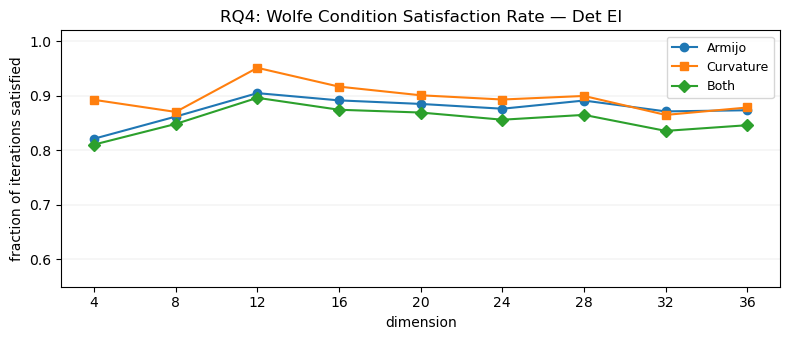

In [11]:
ei_vname = next((vn for vn, _ in VARIANTS if 'det_ei' in vn), None)

if ei_vname is None:
    print('No det_ei variant in VARIANTS — skipping.')
else:
    arm_rates, cur_rates, both_rates = [], [], []
    for dim in available_dims:
        arm_vals, cur_vals, both_vals = [], [], []
        for arm_run, cur_run in zip(
            all_data[ei_vname]['armijo_ok'].get(dim, []),
            all_data[ei_vname]['curvature_ok'].get(dim, []),
        ):
            ac = [v for v in arm_run if v is not None]
            cc = [v for v in cur_run if v is not None]
            bc = [a and c for a, c in zip(ac, cc)]
            if ac:
                arm_vals.append(np.mean(ac))
                cur_vals.append(np.mean(cc))
                both_vals.append(np.mean(bc))
        arm_rates.append(np.mean(arm_vals)   if arm_vals  else np.nan)
        cur_rates.append(np.mean(cur_vals)   if cur_vals  else np.nan)
        both_rates.append(np.mean(both_vals) if both_vals else np.nan)

    fig, ax = plt.subplots(figsize=(8, 3.5))
    ax.plot(available_dims, arm_rates,  'o-', lw=1.5, label='Armijo',    color='#1f77b4')
    ax.plot(available_dims, cur_rates,  's-', lw=1.5, label='Curvature', color='#ff7f0e')
    ax.plot(available_dims, both_rates, 'D-', lw=1.5, label='Both',      color='#2ca02c')

    ax.set_ylim([0.55, 1.02])
    ax.set_xticks(available_dims)
    ax.set_xlabel('dimension')
    ax.set_ylabel('fraction of iterations satisfied')
    ax.yaxis.grid(True, linewidth=0.3, alpha=0.5)
    ax.legend(fontsize=9)
    ax.set_title('RQ4: Wolfe Condition Satisfaction Rate — Det EI')
    plt.tight_layout()
    path = os.path.join(FIGURES_DIR, 'wolfe_satisfaction_det_ei.pdf')
    plt.savefig(path, bbox_inches='tight')
    print(f'Saved: {path}')
    plt.show()